In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing(use_latex='mathjax')   # necessary for appropriate text formatting

In [ ]:
# Define functions and parameters

x = sp.Function('x')   # position

t = sp.Symbol('t')   # time
b = sp.Symbol('beta')   # damping constant
w_0 = sp.Symbol('omega_0')   # natural frequency
f = sp.Symbol('f')   # driving strength (force)
w = sp.Symbol('omega')   # driving strength (force) frequency


x(t), b, w_0, f, w

(x(t), β, ω₀, f, ω)

In [ ]:
# Harmonic oscillator equation with damping

eq_d = sp.Eq(x(t).diff(t, t) + 2 * b * x(t).diff(t) + w_0 * w_0 * x(t), 0)
eq_d

                           2           
    d            2        d            
2⋅β⋅──(x(t)) + ω₀ ⋅x(t) + ───(x(t)) = 0
    dt                      2          
                          dt           

In [ ]:
# Solve harmonic oscillator equation with damping

sol_d = sp.dsolve(eq_d, x(t), ics={x(0): 1, x(t).diff(t).subs(t, 0): 0})
sol_d

                                   ⎛       __________⎞                         ↪
                                   ⎜      ╱  2     2 ⎟                         ↪
       ⎛         β          1⎞  -t⋅⎝β + ╲╱  β  - ω₀  ⎠   ⎛       β          1⎞ ↪
x(t) = ⎜- ─────────────── + ─⎟⋅ℯ                       + ⎜─────────────── + ─⎟ ↪
       ⎜       __________   2⎟                           ⎜     __________   2⎟ ↪
       ⎜      ╱  2     2     ⎟                           ⎜    ╱  2     2     ⎟ ↪
       ⎝  2⋅╲╱  β  - ω₀      ⎠                           ⎝2⋅╲╱  β  - ω₀      ⎠ ↪

↪     ⎛        __________⎞
↪     ⎜       ╱  2     2 ⎟
↪   t⋅⎝-β + ╲╱  β  - ω₀  ⎠
↪ ⋅ℯ                      
↪                         
↪                         
↪                         

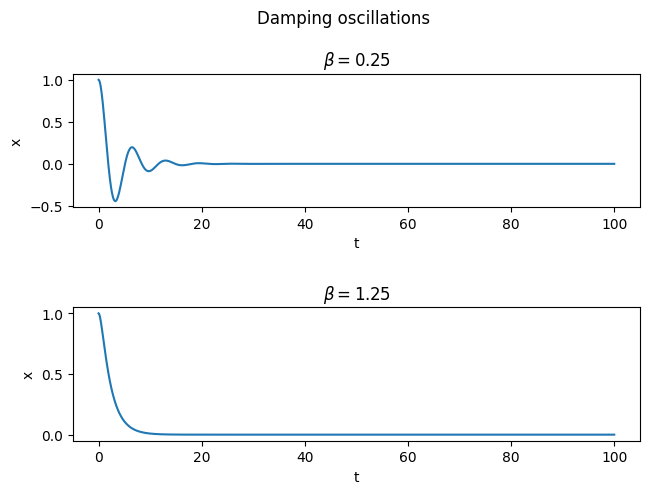

In [44]:
# Plot solutions for different parameters

expr_1 = sol_d.rhs.subs({b: 0.25, w_0: 1})   # under-damping (reducing oscillations)
expr_2 = sol_d.rhs.subs({b: 1.25, w_0: 1})   # above critical damping (immediate disappearance of oscillations)

x_1 = sp.lambdify(t, expr_1, 'numpy')   # convert SymPy to NumPy
x_2 = sp.lambdify(t, expr_2, 'numpy')

t_vals = np.linspace(0, 100, 1000)   # time range
x1 = x_1(t_vals)
x2 = x_2(t_vals)

fig, axs = plt.subplots(2)
fig.suptitle('Damping oscillations \n')
fig.tight_layout()
fig.subplots_adjust(hspace=0.75)
axs[0].set_title(r'$\beta = 0.25$')
axs[0].set(xlabel='t', ylabel='x')
axs[0].plot(t_vals, x1)
axs[1].set_title(r'$\beta = 1.25$')
axs[1].set(xlabel='t', ylabel='x')
axs[1].plot(t_vals, x2)

In [ ]:
# Harmonic oscillator equation with damping and external forcing

eq_f = sp.Eq(x(t).diff(t, t) + 2 * b * x(t).diff(t) + w_0 * w_0 * x(t), f * sp.cos(w * t))
eq_f

                           2                    
    d            2        d                     
2⋅β⋅──(x(t)) + ω₀ ⋅x(t) + ───(x(t)) = f⋅cos(ω⋅t)
    dt                      2                   
                          dt                    

In [ ]:
# Solve harmonic oscillator equation with damping and external forcing

sol_f = sp.dsolve(eq_f, x(t), ics={x(0): 1, x(t).diff(t).subs(t, 0): 0})
sol_f

                                                                               ↪
                                                  2                            ↪
             2⋅β⋅f⋅ω⋅sin(ω⋅t)                  f⋅ω ⋅cos(ω⋅t)                   ↪
x(t) = ───────────────────────────── - ───────────────────────────── + ─────── ↪
          2  2    4      2   2     4      2  2    4      2   2     4      2  2 ↪
       4⋅β ⋅ω  + ω  - 2⋅ω ⋅ω₀  + ω₀    4⋅β ⋅ω  + ω  - 2⋅ω ⋅ω₀  + ω₀    4⋅β ⋅ω  ↪
                                                                               ↪

↪                          ⎛                                                   ↪
↪     2                    ⎜                                              3  2 ↪
↪ f⋅ω₀ ⋅cos(ω⋅t)           ⎜                                           4⋅β ⋅ω  ↪
↪ ────────────────────── + ⎜- ──────────────────────────────────────────────── ↪
↪     4      2   2     4   ⎜             __________           __________       ↪
↪  + ω  - 2⋅ω ⋅ω₀  + ω₀    

c:\Users\Anna\.pyenv\pyenv-win\versions\3.9.6\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Anna\.pyenv\pyenv-win\versions\3.9.6\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


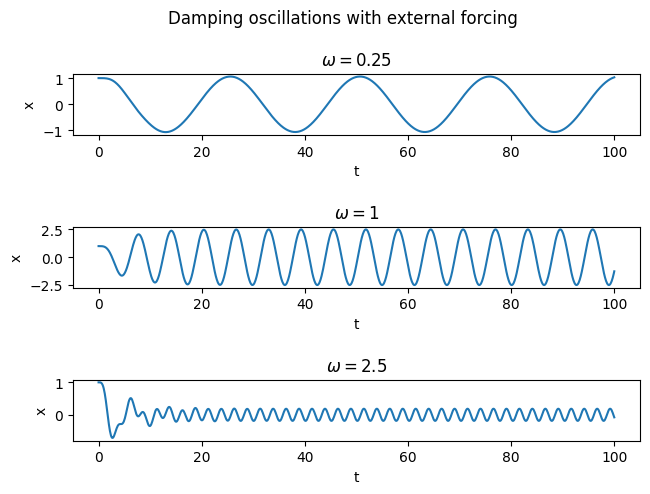

In [47]:
# Plot solutions for different parameters

expr_1 = sol_f.rhs.subs({b: 0.2, w_0: 1, f: 1, w: 0.25})   # below resonance
expr_2 = sol_f.rhs.subs({b: 0.2, w_0: 1, f: 1, w: 1})   # at resonance
expr_3 = sol_f.rhs.subs({b: 0.2, w_0: 1, f: 1, w: 2.5})   # above resonance


x_1 = sp.lambdify(t, expr_1, 'numpy')
x_2 = sp.lambdify(t, expr_2, 'numpy')
x_3 = sp.lambdify(t, expr_3, 'numpy')

t_vals = np.linspace(0, 100, 1000)
x1 = x_1(t_vals)
x2 = x_2(t_vals)
x3 = x_3(t_vals)

fig, axs = plt.subplots(3)
fig.suptitle('Damping oscillations with external forcing \n')
fig.tight_layout()
fig.subplots_adjust(hspace=1.5)
axs[0].set_title(r'$\omega = 0.25$')
axs[0].set(xlabel='t', ylabel='x')
axs[0].plot(t_vals, x1)
axs[1].set_title(r'$\omega = 1$')
axs[1].set(xlabel='t', ylabel='x')
axs[1].plot(t_vals, x2)
axs[2].set_title(r'$\omega = 2.5$')
axs[2].set(xlabel='t', ylabel='x')
axs[2].plot(t_vals, x3)


c:\Users\Anna\.pyenv\pyenv-win\versions\3.9.6\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\Anna\.pyenv\pyenv-win\versions\3.9.6\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


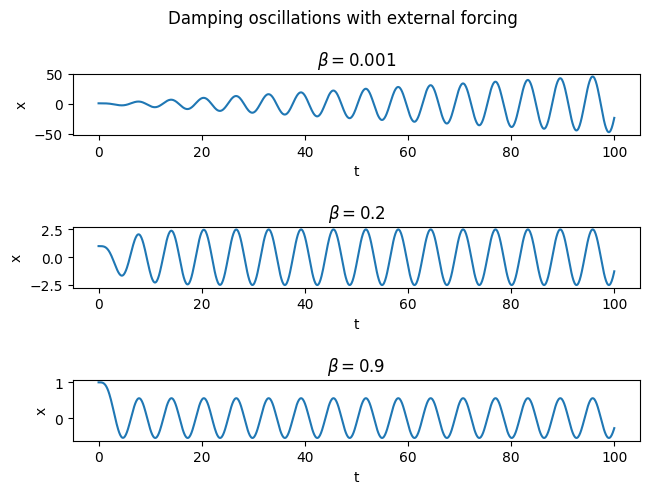

In [48]:
# Plot solutions for different parameters

expr_1 = sol_f.rhs.subs({b: 0.001, w_0: 1, f: 1, w: 1})   # strong resonance
expr_2 = sol_f.rhs.subs({b: 0.2, w_0: 1, f: 1, w: 1})   # moderate damping
expr_3 = sol_f.rhs.subs({b: 0.9, w_0: 1, f: 1, w: 1})   # damped resonance


x_1 = sp.lambdify(t, expr_1, 'numpy')
x_2 = sp.lambdify(t, expr_2, 'numpy')
x_3 = sp.lambdify(t, expr_3, 'numpy')

t_vals = np.linspace(0, 100, 1000)
x1 = x_1(t_vals)
x2 = x_2(t_vals)
x3 = x_3(t_vals)

fig, axs = plt.subplots(3)
fig.suptitle('Damping oscillations with external forcing \n')
fig.tight_layout()
fig.subplots_adjust(hspace=1.5)
axs[0].set_title(r'$\beta = 0.001$')
axs[0].set(xlabel='t', ylabel='x')
axs[0].plot(t_vals, x1)
axs[1].set_title(r'$\beta = 0.2$')
axs[1].set(xlabel='t', ylabel='x')
axs[1].plot(t_vals, x2)
axs[2].set_title(r'$\beta = 0.9$')
axs[2].set(xlabel='t', ylabel='x')
axs[2].plot(t_vals, x3)